# Customer Segmentation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

SEED = 42
SRC = (r"C:\Users\Linh\Desktop\Growth & Experimentation Project for Ride-Hailing "
       r"Promotions\02. Synthetic_data\outputs\customer_features_final.csv")

df = pd.read_csv(SRC)
print(f"{len(df):,} rider x {df.shape[1]} cot")
display(df.head())

20,000 rider x 14 cot


,user_id,age,gender,home_borough,total_rides,recency_days,typical_distance,route_entropy,pct_airport,pref_time_bucket,weekend_ratio,pct_flex_payment,pct_tip_rate,avg_fare
0,1,24,Female,Manhattan,9,69,2.450,2.197225,0.111111,late_night,0.444444,0.333333,0.102761,19.432
1,2,57,Other,Manhattan,3,16,0.890,1.098612,0.000000,morning,0.333333,0.333333,0.392105,8.873
2,3,25,Female,Manhattan,11,12,0.910,2.271869,0.000000,morning,0.454545,0.090909,0.334748,10.872
3,4,52,Female,Manhattan,12,39,3.095,2.484907,0.000000,midday,0.333333,0.333333,0.201553,20.193
4,5,18,Other,Manhattan,1,32,5.610,0.000000,0.000000,morning,0.000000,1.000000,0.000000,36.170


## 1. Kiểm tra chất lượng dữ liệu

Trước khi phân cụm: không thiếu giá trị, không trùng rider, và các biến số nằm trong khoảng hợp lý.

In [2]:
print(f"gia tri thieu        : {df.isnull().sum().sum()}")
print(f"dong trung lap hoan toan: {df.duplicated().sum()}")
print(f"user_id trung        : {df.user_id.duplicated().sum()}")

CHECK = ["total_rides", "recency_days", "typical_distance", "route_entropy",
         "pct_airport", "weekend_ratio", "pct_flex_payment", "pct_tip_rate", "avg_fare"]
display(df[CHECK].describe().round(3))

for c in ["gender", "home_borough", "pref_time_bucket"]:
    print(f"\n{c}:")
    print((df[c].value_counts(normalize=True) * 100).round(1).to_string())

gia tri thieu        : 0
dong trung lap hoan toan: 0
user_id trung        : 0


,total_rides,recency_days,typical_distance,route_entropy,pct_airport,weekend_ratio,pct_flex_payment,pct_tip_rate,avg_fare
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,8.032,56.097,2.637,1.884,0.068,0.294,0.265,0.240,21.314
std,4.868,54.437,2.262,0.663,0.124,0.204,0.201,0.080,9.127
min,1.000,0.000,0.010,0.000,0.000,0.000,0.000,0.000,3.000
25%,4.000,16.000,1.395,1.386,0.000,0.167,0.125,0.203,15.177
50%,7.000,39.000,1.940,1.946,0.000,0.286,0.250,0.248,19.551
75%,11.000,79.000,2.895,2.305,0.111,0.400,0.375,0.286,25.309
max,44.000,277.000,30.310,3.761,1.000,1.000,1.000,1.000,146.500



gender:
gender
Other     33.9
Female    33.2
Male      32.9

home_borough:
home_borough
Manhattan        81.1
Queens           11.7
Brooklyn          6.5
Bronx             0.7
EWR               0.0
Staten Island     0.0

pref_time_bucket:
pref_time_bucket
midday        30.5
evening       27.0
late_night    22.6
morning       20.0


## 2. Chuẩn hoá

In [3]:
from sklearn.preprocessing import StandardScaler

CLUSTER_FEATURES = ["pct_tip_rate", "pct_flex_payment",
                    "pct_airport", "weekend_ratio"]

X = StandardScaler().fit_transform(df[CLUSTER_FEATURES].to_numpy(dtype=float))
print("Ma tran cluster:", X.shape)
print("mean ~ 0:", np.abs(X.mean(0)).max().round(6), " | std ~ 1:", X.std(0).round(4))

Ma tran cluster: (20000, 4)
mean ~ 0: 0.0  | std ~ 1: [1. 1. 1. 1.]


## 3. Chọn K

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

SEED = 42

def null_matrix(X, seed=0):
    rng = np.random.default_rng(seed)
    return np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])])

def choose_k(X, k_range=range(2, 9), seed=SEED, sil_n=8000):
    rng = np.random.default_rng(0)
    sub = rng.choice(len(X), min(sil_n, len(X)), replace=False)
    Xn  = null_matrix(X, seed)
    rows = []
    for k in k_range:
        km = KMeans(k, n_init=10, random_state=seed).fit(X)
        kn = KMeans(k, n_init=10, random_state=seed).fit(Xn)
        a  = KMeans(k, n_init=10, random_state=seed + 1).fit_predict(X)
        b  = KMeans(k, n_init=10, random_state=seed + 2).fit_predict(X)
        rows.append({
            "k": k,
            "silhouette": silhouette_score(X[sub], km.labels_[sub]),
            "silhouette_null": silhouette_score(Xn[sub], kn.labels_[sub]),
            "inertia": km.inertia_,
            "ari_2_seed": adjusted_rand_score(a, b),
            "min_share": pd.Series(km.labels_).value_counts(normalize=True).min(),
        })
    t = pd.DataFrame(rows)
    t["sil_gap"] = t.silhouette - t.silhouette_null
    return t

ktab = choose_k(X)
BEST_K = int(ktab.loc[ktab.sil_gap.idxmax(), "k"])
display(ktab.round(4))
print(f"K duoc chon = {BEST_K}")

,k,silhouette,silhouette_null,inertia,ari_2_seed,min_share,sil_gap
0,2,0.2838,0.2874,65945.8992,0.9995,0.1700,-0.0036
1,3,0.2304,0.1910,53703.6556,0.9930,0.1465,0.0394
2,4,0.2068,0.2009,45962.8870,0.9653,0.1105,0.0059
3,5,0.2052,0.2235,40666.3440,0.9937,0.0560,-0.0184
4,6,0.1985,0.1947,37051.9458,0.9964,0.0368,0.0038
5,7,0.2018,0.1931,34466.6218,0.9859,0.0312,0.0087
6,8,0.1924,0.1974,32214.9230,0.9892,0.0300,-0.0050


K duoc chon = 3


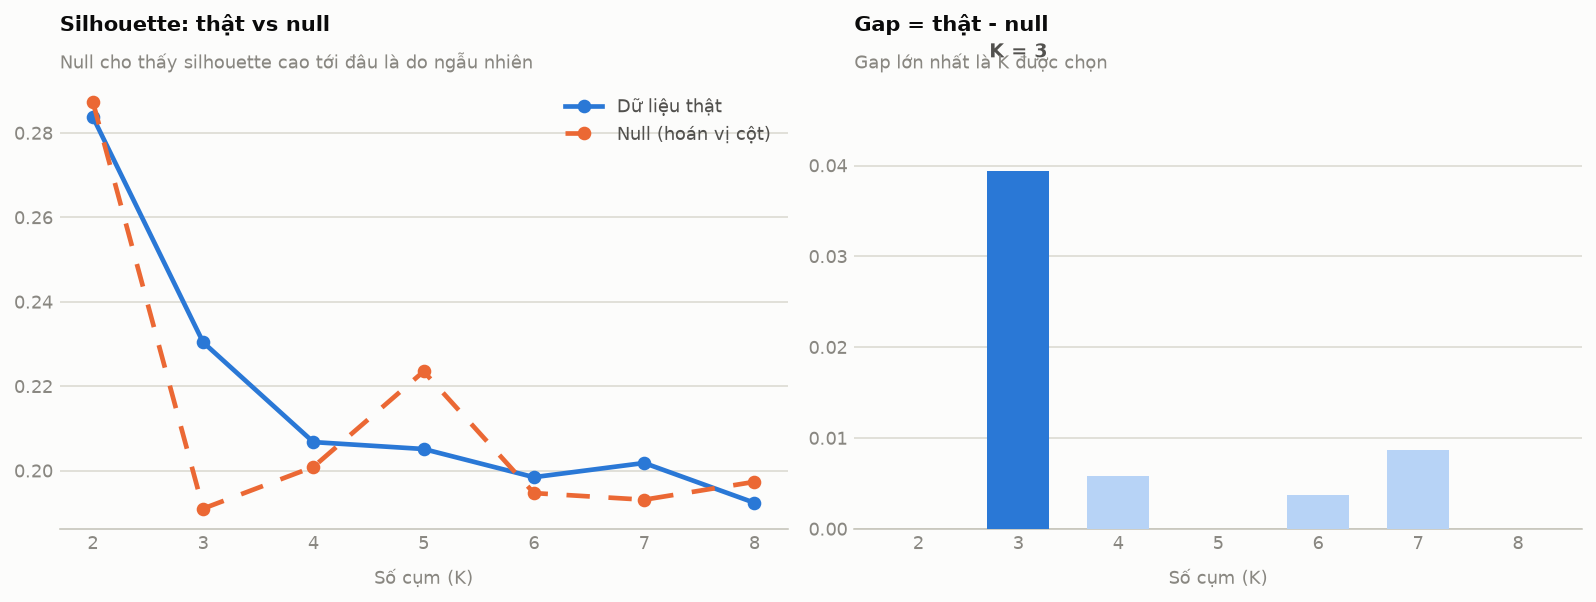

In [5]:
SURFACE, INK, SECOND, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SERIES, ALT     = "#e1e0d9", "#c3c2b7", "#2a78d6", "#eb6834"

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), dpi=140)
fig.patch.set_facecolor(SURFACE)

ax = axes[0]; ax.set_facecolor(SURFACE)
ax.plot(ktab.k, ktab.silhouette, color=SERIES, lw=2.4, marker="o", ms=6,
        zorder=4, label="Dữ liệu thật")
ax.plot(ktab.k, ktab.silhouette_null, color=ALT, lw=2.4, marker="o", ms=6,
        ls=(0, (5, 4)), zorder=4, label="Null (hoán vị cột)")
ax.set_title("Silhouette: thật vs null", color=INK, fontsize=11,
             fontweight="bold", loc="left", pad=26)
ax.text(0, 1.02, "Null cho thấy silhouette cao tới đâu là do ngẫu nhiên",
        transform=ax.transAxes, color=MUTED, fontsize=9, va="bottom")
leg = ax.legend(frameon=False, fontsize=9.5, loc="upper right")
for t in leg.get_texts(): t.set_color(SECOND)

ax = axes[1]; ax.set_facecolor(SURFACE)
bars = ax.bar(ktab.k, ktab.sil_gap, color=[SERIES if k == BEST_K else "#b7d3f6"
                                           for k in ktab.k], width=0.62, zorder=3)
ax.text(BEST_K, ktab.sil_gap.max() + 0.012, f"K = {BEST_K}", ha="center",
        va="bottom", color=SECOND, fontsize=10, fontweight="bold")
ax.set_title("Gap = thật - null", color=INK, fontsize=11,
             fontweight="bold", loc="left", pad=26)
ax.text(0, 1.02, "Gap lớn nhất là K được chọn", transform=ax.transAxes,
        color=MUTED, fontsize=9, va="bottom")
ax.set_ylim(0, ktab.sil_gap.max() * 1.25)

for ax in axes:
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRID, lw=1); ax.xaxis.grid(False)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
    ax.set_xlabel("Số cụm (K)", color=MUTED, fontsize=9, labelpad=8)
    ax.set_xticks(ktab.k)

plt.tight_layout(); plt.show()

## 4. Phân cụm

In [7]:
km = KMeans(BEST_K, n_init=10, random_state=SEED).fit(X)
df["cluster"] = km.labels_

size = (df.cluster.value_counts(normalize=True).sort_index() * 100).round(2)
print("Quy mo tung cum (%):"); print(size.to_string())

Quy mo tung cum (%):
cluster
0    54.96
1    30.39
2    14.65


## 5. Lập hồ sơ persona

In [8]:
# Truc MO TA — khong vao KMeans, chi dung de lap ho so persona
PROFILE_FEATURES = ["typical_distance", "avg_fare", "weekend_ratio",
                    "pref_time_bucket", "home_borough"]

z = (df[CLUSTER_FEATURES] - df[CLUSTER_FEATURES].mean()) / df[CLUSTER_FEATURES].std()
z["cluster"] = df.cluster

prof = z.groupby("cluster").mean().round(2)
prof.columns = [f"z_{c}" for c in prof.columns]
prof.insert(0, "share_%", (df.cluster.value_counts(normalize=True) * 100).round(2))
prof.insert(0, "n", df.cluster.value_counts())

num = [c for c in PROFILE_FEATURES if pd.api.types.is_numeric_dtype(df[c])]
prof = prof.join(df.groupby("cluster")[num].mean().round(2))
prof = prof.join(df.groupby("cluster")[["total_rides"]].mean().round(2)
                 .rename(columns={"total_rides": "rides_TB"}))
display(prof.sort_index())

print("Khung gio troi cua tung cum (%):")
display((pd.crosstab(df.cluster, df.pref_time_bucket, normalize="index") * 100).round(1))

,n,share_%,z_pct_tip_rate,z_pct_flex_payment,z_pct_airport,z_weekend_ratio,typical_distance,avg_fare,weekend_ratio,rides_TB
cluster,,,,,,,,,,
0,10992,54.96,0.31,-0.40,-0.34,-0.34,1.93,17.79,0.23,8.43
1,6078,30.39,-0.44,0.92,-0.31,0.62,2.75,22.15,0.42,7.58
2,2930,14.65,-0.24,-0.40,1.94,-0.03,5.04,32.81,0.29,7.49


Khung gio troi cua tung cum (%):


pref_time_bucket,evening,late_night,midday,morning
cluster,,,,
0,29.3,16.9,33.2,20.7
1,23.6,32.7,24.6,19.2
2,25.5,22.7,32.9,18.9


## 6. Chọn nhóm target và xuất kết quả

In [9]:
# Lưu data các cụm vào file
import os

OUTDIR = (r"c:/Users/Linh/Desktop/Growth & Experimentation Project for Ride-Hailing "
          r"Promotions/03. Segmentation/outputs")
os.makedirs(OUTDIR, exist_ok=True)

# Tu tinh ho so z-score o day thay vi dung bien `prof` cua cell 21, de cell nay
# chay duoc doc lap — khong phu thuoc vao viec da chay cell nao truoc do.
zp = (df[CLUSTER_FEATURES] - df[CLUSTER_FEATURES].mean()) / df[CLUSTER_FEATURES].std()
zp["cluster"] = df.cluster
zprof = zp.groupby("cluster").mean().round(3)
zprof.columns = [f"z_{c}" for c in zprof.columns]

# Ten dat theo TRUC DAC TRUNG cua tung cum (xem phan dien giai ben duoi).
NAMES = {
    0: "Khach noi do ngay thuong, tip cao",
    1: "Khach cuoi tuan, tra Flex, tip thap",
    2: "Khach san bay / duong dai",
}
TARGET_CLUSTER = 1      # nhom chon de A/B test

sig = {
    0: ("z_pct_tip_rate",     "max"),
    1: ("z_pct_flex_payment", "max"),
    2: ("z_pct_airport",      "max"),
}
for k, (axis, how) in sig.items():
    got = zprof[axis].idxmax() if how == "max" else zprof[axis].idxmin()
    assert got == k, (f"Cum {k} dang le co {axis} {how} nhung thuc te la cum {got}. "
                      f"Nhan cum da hoan vi — cap nhat lai NAMES truoc khi luu.")

# 1. Nhan cap rider — file ma buoc A/B testing se doc
rider = df[["user_id"]].copy()
rider["cluster"]   = df.cluster
rider["persona"]   = df.cluster.map(NAMES)
rider["is_target"] = (df.cluster == TARGET_CLUSTER).astype(int)
rider.to_csv(os.path.join(OUTDIR, "rider_cluster.csv"), index=False)

# 2. Ho so tung cum: z-score cac truc phan cum + vai chi so kinh doanh
out = zprof.copy()
out.insert(0, "share_%", (df.cluster.value_counts(normalize=True) * 100).round(2))
out.insert(0, "n", df.cluster.value_counts())
out.insert(0, "persona", out.index.map(NAMES))
out = out.join(df.groupby("cluster")[["total_rides", "typical_distance",
                                      "avg_fare", "weekend_ratio"]].mean().round(2))
out.sort_index().to_csv(os.path.join(OUTDIR, "cluster_profiles.csv"))

# 3. Toan bo feature cua nhom target
tg = df[df.cluster == TARGET_CLUSTER].drop(columns=["cluster"])
tg.to_csv(os.path.join(OUTDIR, "target_riders.csv"), index=False)

print(f"Da luu vao {OUTDIR}\n")
for fn in sorted(os.listdir(OUTDIR)):
    p = os.path.join(OUTDIR, fn)
    print(f"   {fn:<24} {os.path.getsize(p):>9,} bytes")

print(f"\nrider_cluster.csv : {len(rider):,} dong x {rider.shape[1]} cot")
print(f"target_riders.csv : {len(tg):,} rider thuoc Cum {TARGET_CLUSTER}")
print(f"\nQuy mo tung cum:")
for k in sorted(NAMES):
    n = int((df.cluster == k).sum())
    mark = "  <- TARGET" if k == TARGET_CLUSTER else ""
    print(f"   Cum {k}  {NAMES[k]:<46} {n:>6,}  ({n/len(df):>5.1%}){mark}")

Da luu vao c:/Users/Linh/Desktop/Growth & Experimentation Project for Ride-Hailing Promotions/03. Segmentation/outputs

   cluster_profiles.csv           428 bytes
   rider_cluster.csv          911,785 bytes
   target_riders.csv          522,808 bytes

rider_cluster.csv : 20,000 dong x 4 cot
target_riders.csv : 6,078 rider thuoc Cum 1

Quy mo tung cum:
   Cum 0  Khach noi do ngay thuong, tip cao              10,992  (55.0%)
   Cum 1  Khach cuoi tuan, tra Flex, tip thap             6,078  (30.4%)  <- TARGET
   Cum 2  Khach san bay / duong dai                       2,930  (14.6%)


### Diễn giải 3 cụm

**Cụm 0 — Khách nội đô ngày thường, tip cao (55.0%, 10,992 rider)**
`z_pct_tip_rate = +0.31` cao nhất, cả ba trục còn lại đều âm: ít Flex (−0.40), ít sân bay (−0.34), ít cuối tuần (−0.34). Quãng đường 1.93 dặm và cước 17.79 — thấp nhất. Trội khung `midday` (33.2%) và `morning` (20.7%) — cao nhất trong ba cụm.
*Ý nghĩa:* đi lại nội đô trong giờ hành chính, chặng ngắn, giá trị mỗi chuyến thấp nhưng chịu tip. Đông nhất nên đóng góp khối lượng chính.

**Cụm 1 — Khách cuối tuần, trả Flex, tip thấp (30.4%, 6,078 rider)**
Định danh bằng `z_pct_flex_payment = +0.92` đi kèm `z_weekend_ratio = +0.62` (tỷ lệ cuối tuần 0.42, cao nhất). Tip thấp nhất (−0.44). Trội khung `late_night` 32.7% — cao hơn hẳn hai cụm kia.
*Ý nghĩa:* nhu cầu đi chơi và về khuya, thanh toán linh hoạt, ít chịu tip.

**Cụm 2 — Khách sân bay / đường dài (14.6%, 2,930 rider)**
`z_pct_airport = +1.94`, vượt xa mọi cụm khác. Quãng đường 5.04 dặm (gấp 2.6 lần cụm 0) và cước 32.81 — cao nhất.
*Ý nghĩa:* nhóm nhỏ nhất nhưng doanh thu mỗi chuyến cao nhất.

**Chọn cụm cho A/B test: Cụm 1.** Với mục tiêu tăng incremental trips, cụm 1 là nhóm nhạy giá nhất — tip thấp nhất trong ba cụm, và tỷ lệ trả Flex cao cho thấy họ để tâm tới cách thanh toán. Cụm 0 tuy đông gấp đôi nhưng đã đi đều đặn trong tuần, voucher dễ rơi vào chuyến vốn dĩ sẽ xảy ra. Cụm 2 thì nhu cầu gắn với lịch bay nên khó dịch chuyển bằng khuyến mãi.